In [3]:
import sys
from rdkit import Chem

In [4]:
%load_ext autoreload
%autoreload 2
# Добавляем путь к src для импорта модулей
sys.path.append('src')
from src import MoleculeRenderer


In [5]:
def draw_mol(mol, title="", highlight_atoms=None, display_props=None):
    mr = MoleculeRenderer()
    display(mr.render_2d(mol, title, highlight_atoms, display_props))


In [6]:


def create_dendrimer_with_metadata():
    """Создаем дендример и вручную добавляем метаданные на атомы"""

    # Создаем молекулу дендримера
    smiles = "NCCNC(=O)CCN(CCC(=O)NCCN)CCN(CCC(=O)NCCN)CCC(=O)NCCN"
    mol = Chem.MolFromSmiles(smiles)

    ethylenediamine_original_indices = [0, 1, 2, 3]  # исходные индексы из этилендиамина
    methyl_acrylate_original_indices = [0, 1, 2, 5]  # исходные индексы из метилакрилата
    # Ядро - поколение 0
    for original_idx, i in zip(ethylenediamine_original_indices, [8, 17, 18, 19]):
        atom = mol.GetAtomWithIdx(i)
        atom.SetProp("generation", "0")
        atom.SetProp("branch", "-1")
        atom.SetProp("step", "-1")
        atom.SetProp("original_index", str(original_idx))

    # Поколение 1, ветвь 0, шаг 0
    for original_idx, i in zip(reversed(methyl_acrylate_original_indices), [5, 4, 6, 7]):
        atom = mol.GetAtomWithIdx(i)
        atom.SetProp("generation", "1")
        atom.SetProp("branch", "0")
        atom.SetProp("step", "0")
        atom.SetProp("original_index", str(original_idx))

    # Поколение 1, ветвь 0, шаг 1
    for original_idx, i in zip(reversed(ethylenediamine_original_indices), [0, 1, 2, 3]):
        atom = mol.GetAtomWithIdx(i)
        atom.SetProp("generation", "1")
        atom.SetProp("branch", "0")
        atom.SetProp("step", "1")
        atom.SetProp("original_index", str(original_idx))

    # Поколение 1, ветвь 1, шаг 0
    for original_idx, i in zip(methyl_acrylate_original_indices, [9, 10, 11, 12]):
        atom = mol.GetAtomWithIdx(i)
        atom.SetProp("generation", "1")
        atom.SetProp("branch", "1")
        atom.SetProp("step", "0")
        atom.SetProp("original_index", str(original_idx))

    # Поколение 1, ветвь 1, шаг 1
    for original_idx, i in zip(ethylenediamine_original_indices, [13, 14, 15, 16]):
        atom = mol.GetAtomWithIdx(i)
        atom.SetProp("generation", "1")
        atom.SetProp("branch", "1")
        atom.SetProp("step", "1")
        atom.SetProp("original_index", str(original_idx))

    # Поколение 1, ветвь 2, шаг 0
    for original_idx, i in zip(methyl_acrylate_original_indices, [20, 21, 22, 23]):
        atom = mol.GetAtomWithIdx(i)
        atom.SetProp("generation", "1")
        atom.SetProp("branch", "2")
        atom.SetProp("step", "0")
        atom.SetProp("original_index", str(original_idx))

    # Поколение 1, ветвь 2, шаг 1
    for original_idx, i in zip(ethylenediamine_original_indices, [24, 25, 26, 27]):
        atom = mol.GetAtomWithIdx(i)
        atom.SetProp("generation", "1")
        atom.SetProp("branch", "2")
        atom.SetProp("step", "1")
        atom.SetProp("original_index", str(original_idx))

    # Поколение 1, ветвь 3, шаг 0
    for original_idx, i in zip(methyl_acrylate_original_indices, [28, 29, 30, 31]):
        atom = mol.GetAtomWithIdx(i)
        atom.SetProp("generation", "1")
        atom.SetProp("branch", "3")
        atom.SetProp("step", "0")
        atom.SetProp("original_index", str(original_idx))

    # Поколение 1, ветвь 3, шаг 1
    for original_idx, i in zip(ethylenediamine_original_indices, [32, 33, 34, 35]):
        atom = mol.GetAtomWithIdx(i)
        atom.SetProp("generation", "1")
        atom.SetProp("branch", "3")
        atom.SetProp("step", "1")
        atom.SetProp("original_index", str(original_idx))

    return mol

In [7]:
# Тестирование модуля core.index_tracker
print("\n=== Тестирование IndexTracker ===")
from src import IndexTracker

mol = create_dendrimer_with_metadata()  # Ваша функция
tracker = IndexTracker(mol)


=== Тестирование IndexTracker ===


=== Все атомы (без фильтров) ===
Все атомы: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]


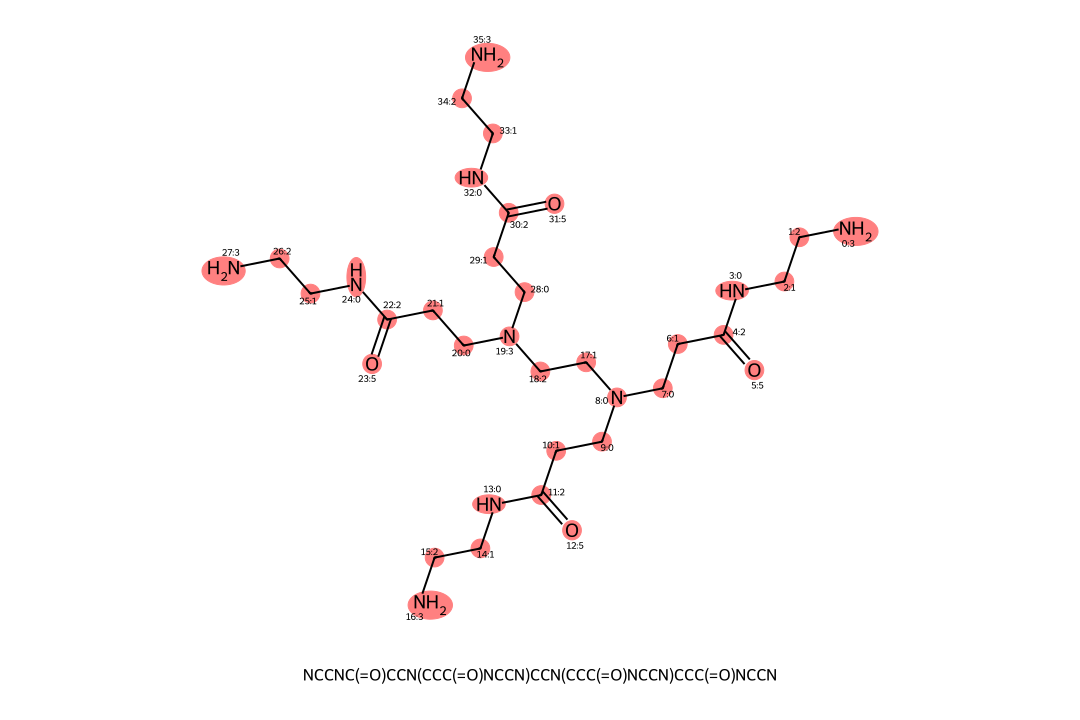

In [8]:
print("=== Все атомы (без фильтров) ===")
all_atoms = tracker.get_atoms()
print(f"Все атомы: {all_atoms}")
draw_mol(mol, highlight_atoms=all_atoms, display_props=['original_index'])


=== Только ветвь 0 ===
ветвь 0: [0, 1, 2, 3, 4, 5, 6, 7]


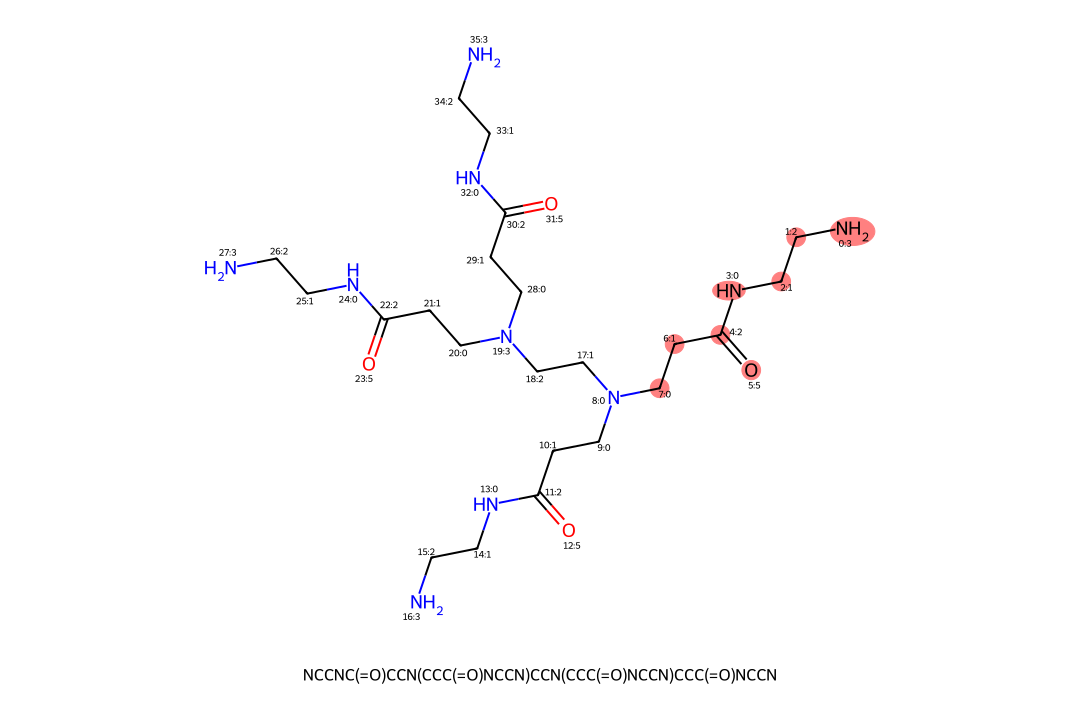


=== Только ветвь 1 ===
ветвь 1: [9, 10, 11, 12, 13, 14, 15, 16]


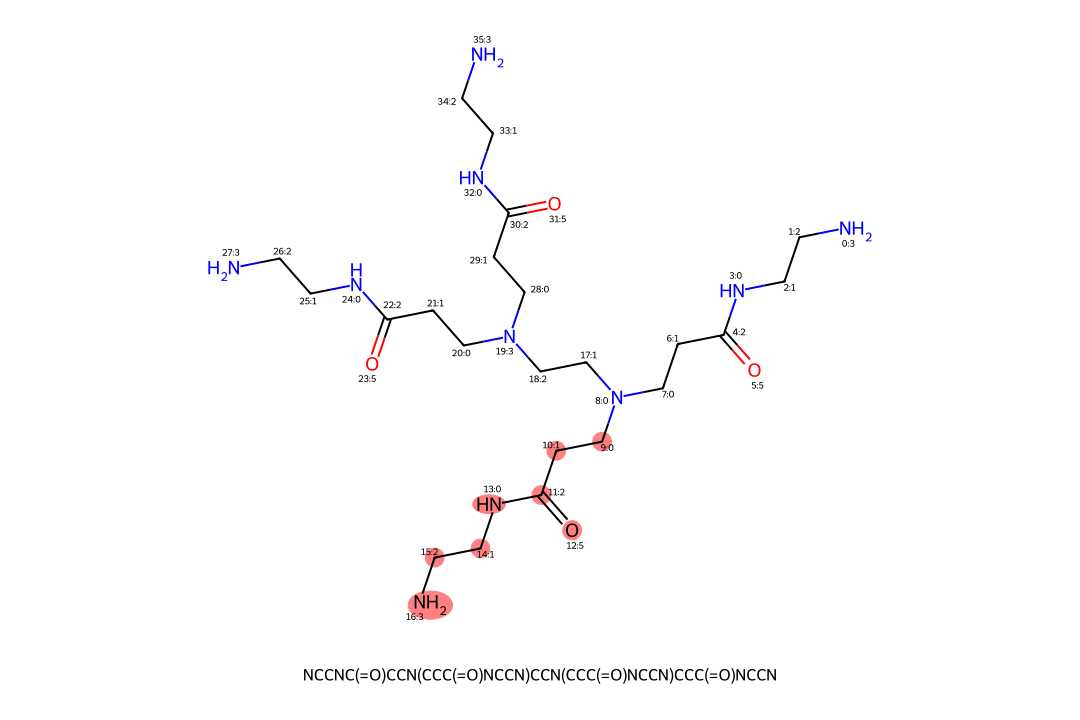


=== Только ветвь 2 ===
ветвь 2: [20, 21, 22, 23, 24, 25, 26, 27]


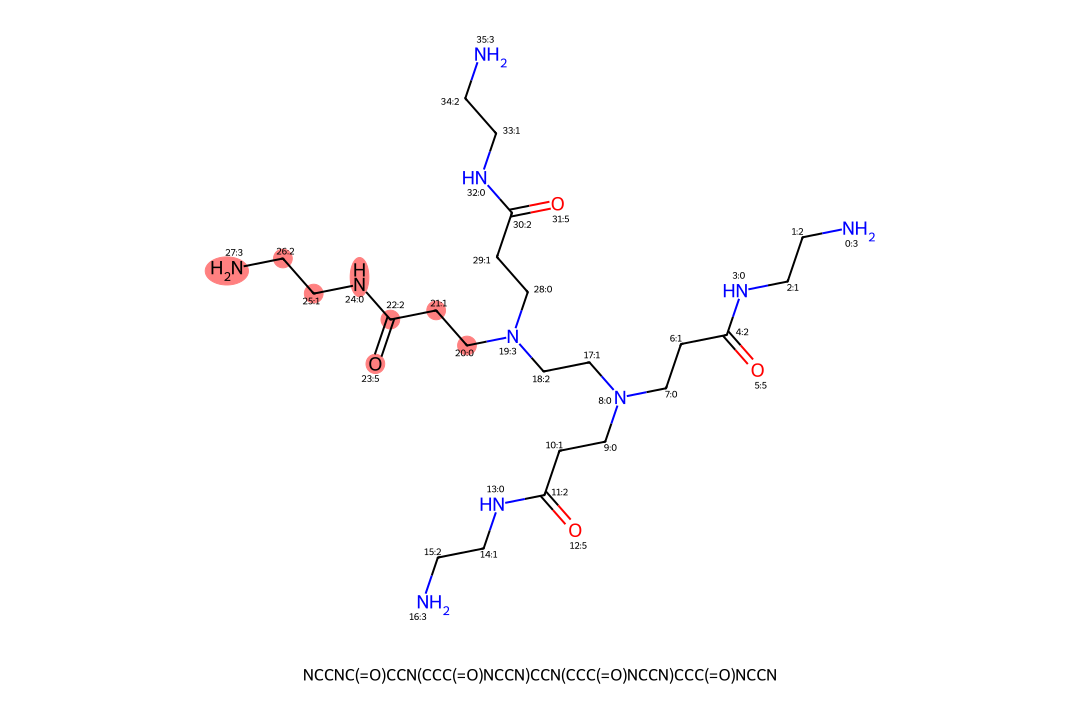


=== Только ветвь 3 ===
ветвь 3: [28, 29, 30, 31, 32, 33, 34, 35]


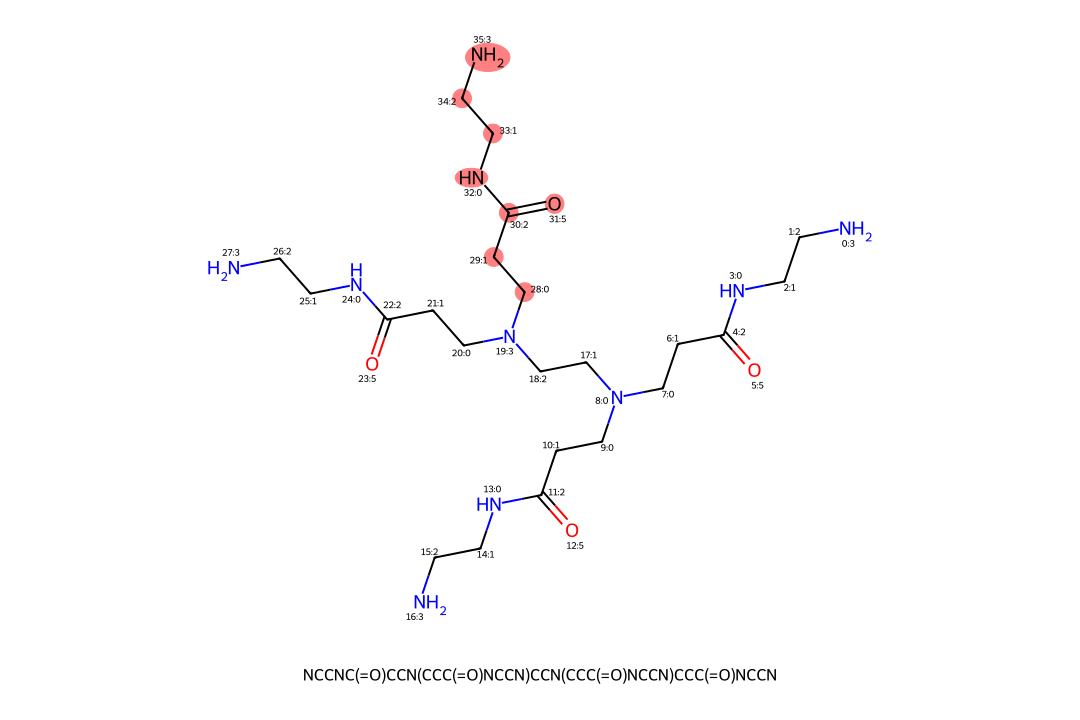

In [9]:
for branch in range(4):
    print(f"\n=== Только ветвь {branch} ===")
    branch_atoms = tracker.get_atoms(branches=[branch])
    print(f"ветвь {branch}: {branch_atoms}")
    draw_mol(mol, highlight_atoms=branch_atoms,display_props=["original_index"])


=== Только первыЙ шаг во всех поколениях ===
Шаги 0-1: [4, 5, 6, 7, 9, 10, 11, 12, 20, 21, 22, 23, 28, 29, 30, 31]


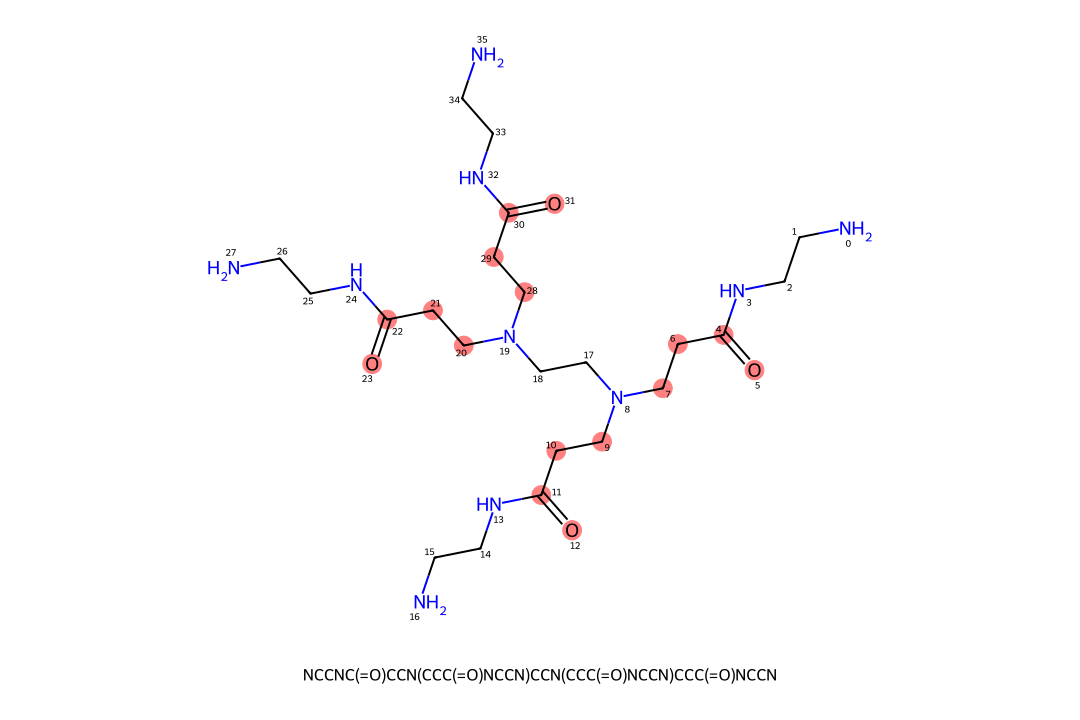

In [10]:
print("\n=== Только первыЙ шаг во всех поколениях ===")
step_0 = tracker.get_atoms(steps=[0])
print(f"Шаги 0-1: {step_0}")
draw_mol(mol, highlight_atoms=step_0)


=== Только поколение 1 ===
Поколение 1: [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]


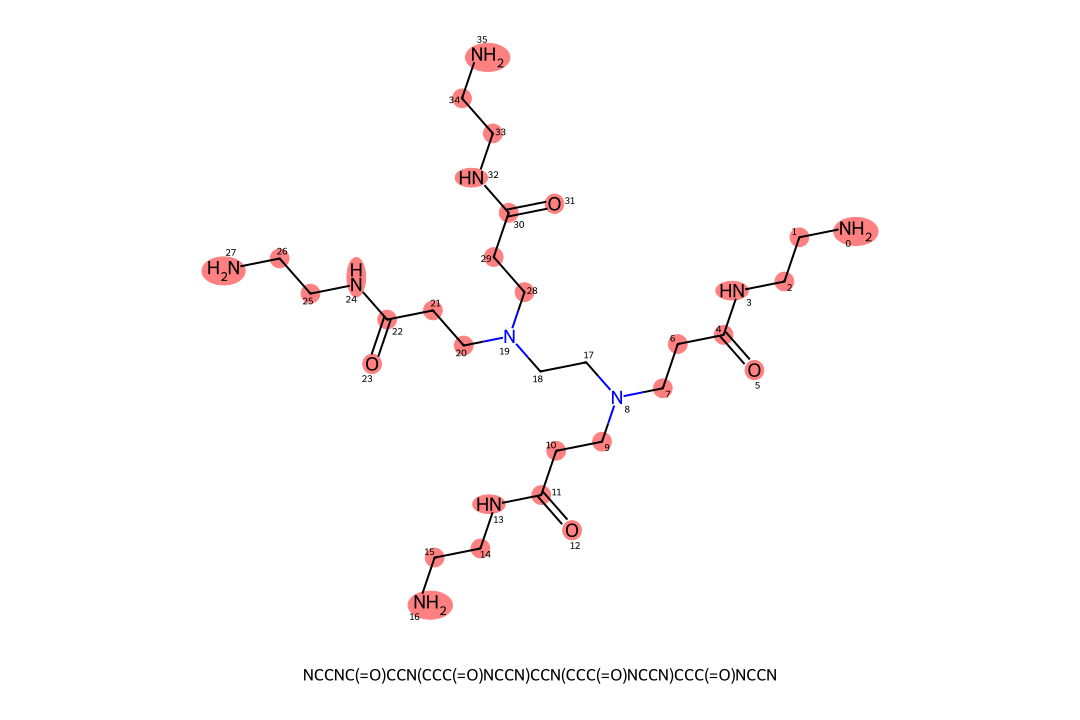

In [11]:
print("\n=== Только поколение 1 ===")
gen1_only = tracker.get_atoms(generations=[1])
print(f"Поколение 1: {gen1_only}")
draw_mol(mol, highlight_atoms=gen1_only)


=== Поколение 1, шаги 0-1 ===
Поколение 1, шаги 0-1: [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]


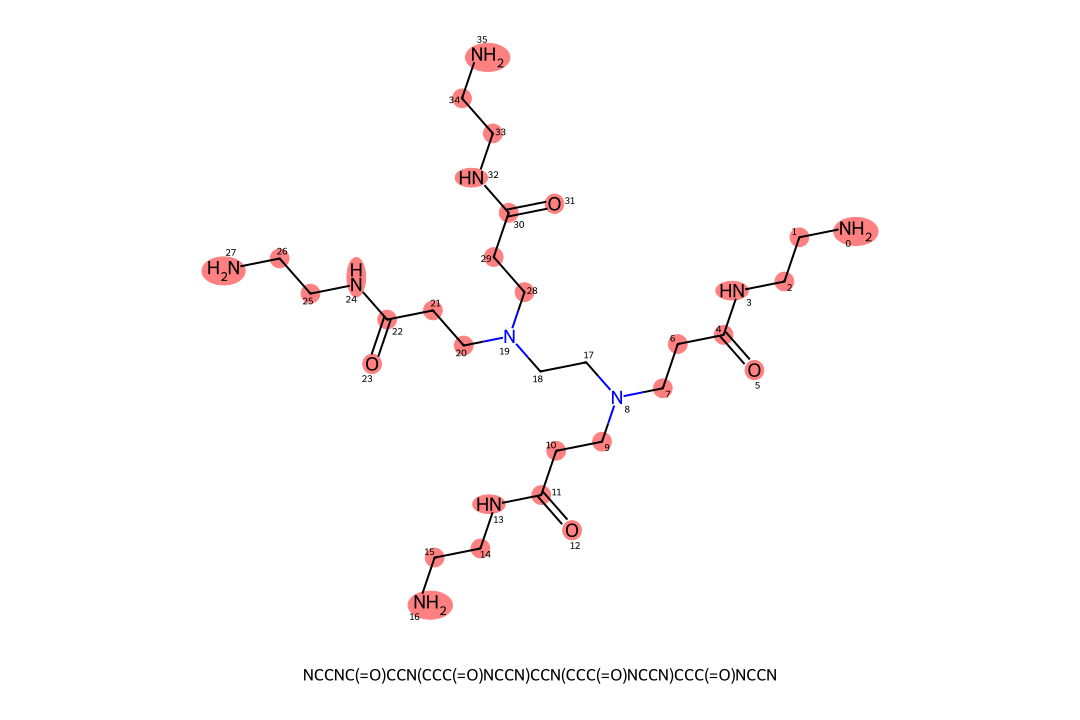

In [12]:

print("\n=== Поколение 1, шаги 0-1 ===")
gen1_steps01 = tracker.get_atoms(generations=[1], steps=[0, 1])
print(f"Поколение 1, шаги 0-1: {gen1_steps01}")
draw_mol(mol, highlight_atoms=gen1_steps01)


=== Ветви 0 и 1 во всех поколениях ===
Ветви 0,1: [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]


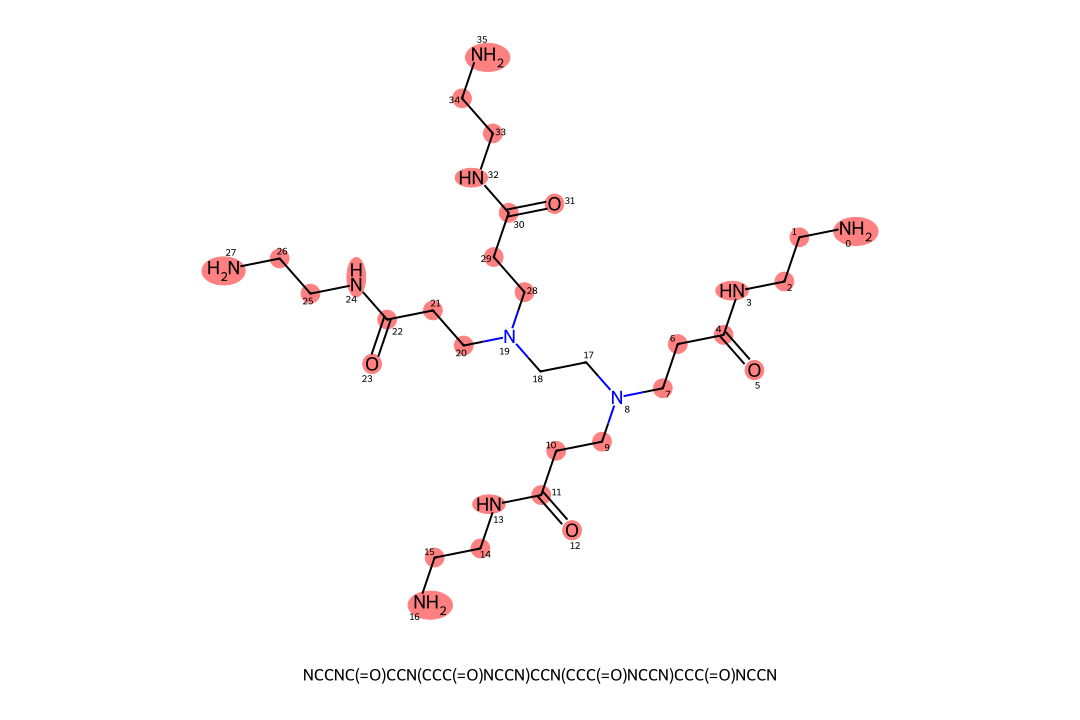

In [13]:

print("\n=== Ветви 0 и 1 во всех поколениях ===")
branches01 = tracker.get_atoms(branches=range(0,4))
print(f"Ветви 0,1: {branches01}")
draw_mol(mol, highlight_atoms=branches01)


=== Сложный фильтр: поколение 1, ветви 0-1, шаги 1 ===
Сложный фильтр: [0, 1, 2, 3, 13, 14, 15, 16]


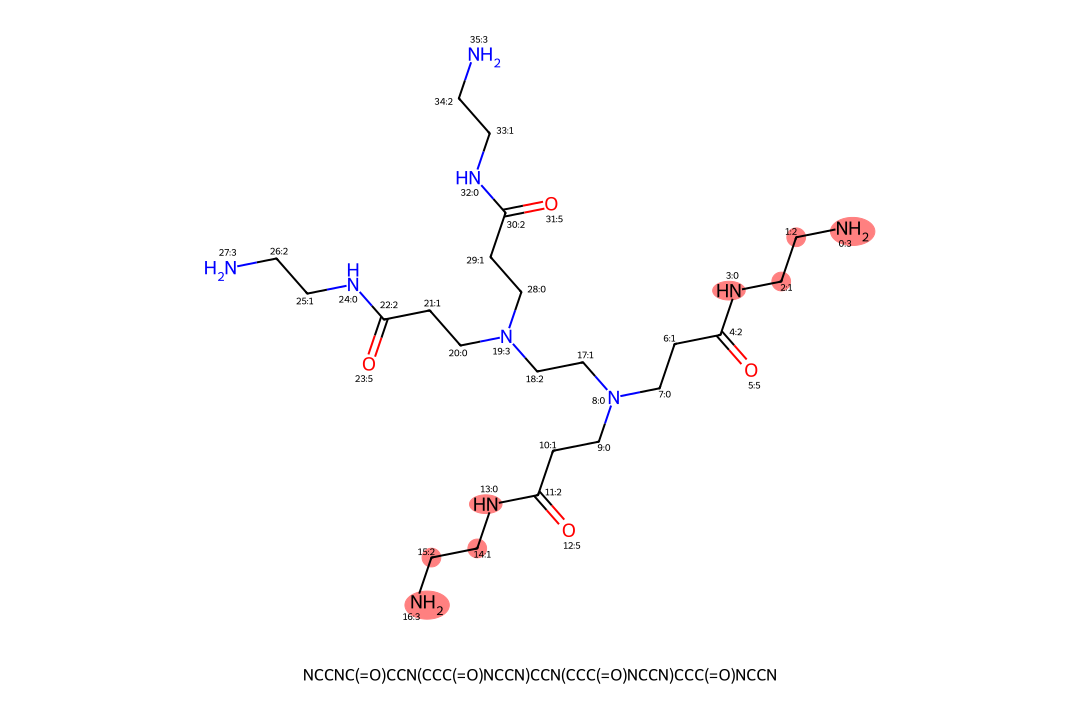

In [14]:

print("\n=== Сложный фильтр: поколение 1, ветви 0-1, шаги 1 ===")
complex_filter = tracker.get_atoms(
    generations=[1],
    branches=[0, 1],
    steps=[1]
)
print(f"Сложный фильтр: {complex_filter}")
draw_mol(mol, highlight_atoms=complex_filter,display_props=["original_index"])


=== Только шаг 0 в ветви 0 ===
Шаг 0, ветвь 0: [4, 5, 6, 7]


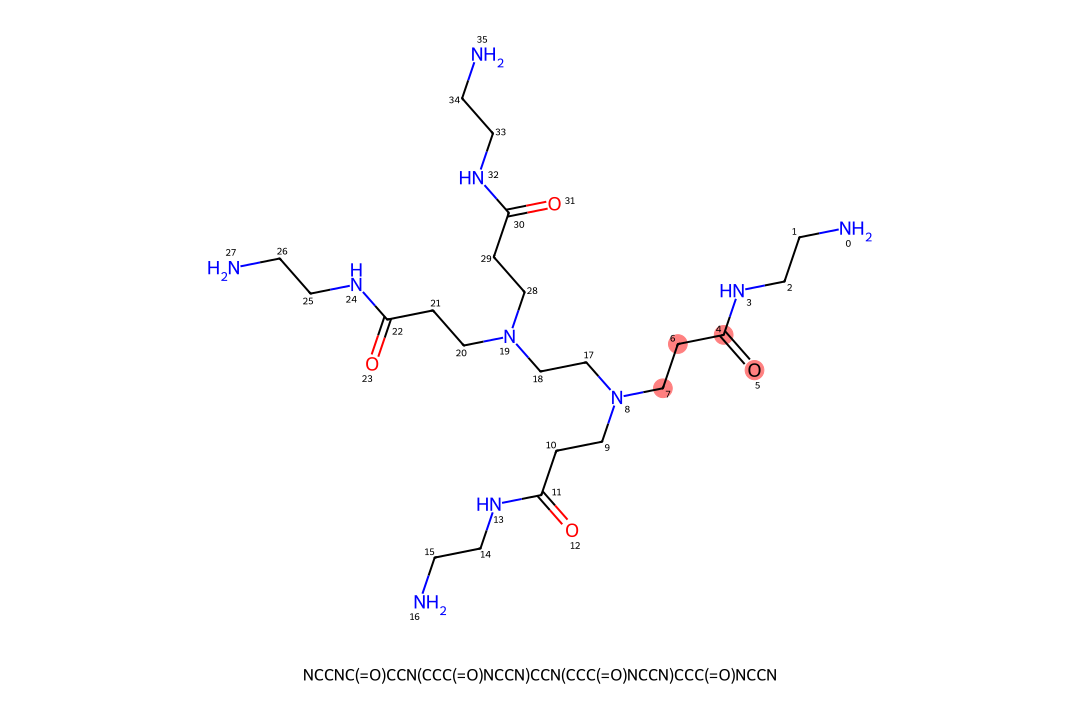

In [15]:

print("\n=== Только шаг 0 в ветви 0 ===")
step0_branch0 = tracker.get_atoms(branches=[0], steps=[0])
print(f"Шаг 0, ветвь 0: {step0_branch0}")
draw_mol(mol, highlight_atoms=step0_branch0)

